In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [2]:
torch.manual_seed(42)

In [3]:
df = pd.read_csv('fmnist_small.csv')
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,...,0,7,0,50,205,196,213,165,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,...,142,142,142,21,0,3,0,0,0,0
3,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,8,0,0,0,0,0,0,0,0,0,...,213,203,174,151,188,10,0,0,0,0


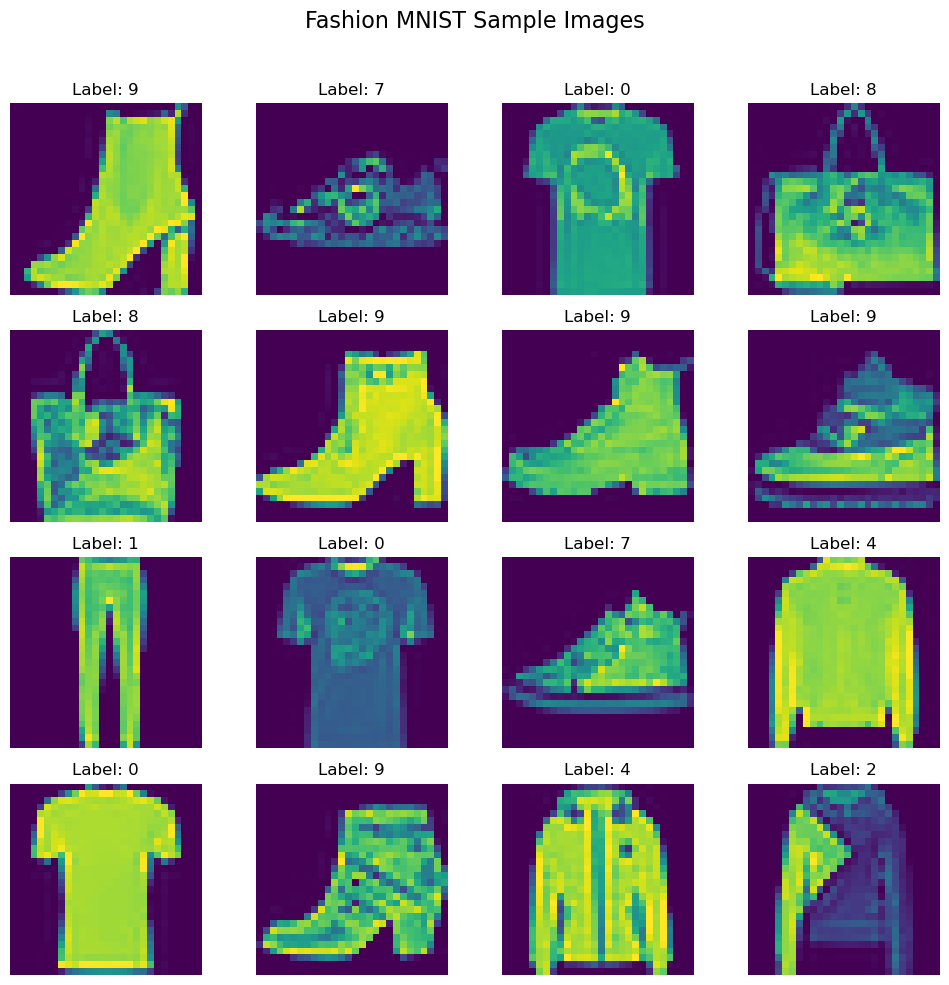

In [4]:
fig,axes = plt.subplots(nrows=4,ncols=4,figsize=(10,10))
fig.suptitle('Fashion MNIST Sample Images', fontsize=16)


for i, ax in enumerate(axes.flatten()):
    image = df.iloc[i, 1:].values.reshape(28, 28) 
    label = df.iloc[i, 0]  
    ax.imshow(image)  
    ax.set_title(f'Label: {label}') 
    ax.axis('off')  
    ax.set_xlabel(f"label : {df.iloc[i,0]}")
    
plt.tight_layout(rect=[0,0,1,0.96])  
plt.show()

In [5]:
X = df.iloc[:, 1:].values  
y = df.iloc[:, 0].values  

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [8]:
class CustomDataset(Dataset):
    def __init__(self, features, labels):
        self.X = torch.tensor(features, dtype=torch.float32)  # convert to tensor
        self.y = torch.tensor(labels, dtype=torch.long)     # convert to tensor

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [9]:
train_dataset = CustomDataset(X_train, y_train)

In [10]:
test_dataset = CustomDataset(X_test, y_test)

In [11]:
len(train_dataset)
len(test_dataset)

1200

In [12]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [13]:
class MyNN(nn.Module):
    def __init__(self,input_dim,out_dim,num_hidden_later,neuron_per_layer):
        
        super().__init__() 
        layers = []
        
        for  i in range(num_hidden_later):
            layers.append(nn.Linear(input_dim,neuron_per_layer))  # 784,128
            layers.append(nn.ReLU())  # Add activation function after each hidden layer
            layers.append(nn.Dropout(0.2))  # Add dropout for regularization
            input_dim = neuron_per_layer  # Update input_dim for the next layer
        
        layers.append(nn.Linear(input_dim,out_dim))  # 128,10
        
        self.model = nn.Sequential(*layers)  # Unpack the layers into Sequential
        
    def forward(self,x):
        return self.model(x)

In [14]:
def objective_function(trial):
    # next hyper parameter values from the search space
    num_hidden_layer = trial.suggest_int('num_hidden_layer', 1, 5)
    nueron_per_layer = trial.suggest_int('nueron_per_layer', 8, 128,step=8)
    
    # model init
    input_dim = 784
    output_dim = 10
    
    model = MyNN(input_dim, output_dim, num_hidden_layer, nueron_per_layer)
    
    # para init
    learning_rate = 0.1
    num_epochs = 100
    
    # optimizer selection
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate,weight_decay=1e-4)
    
    # training loop
    for epoch in range(num_epochs):

        for batch_feature, batch_labels in train_loader:
            # forward pass
            outputs = model(batch_feature)
            
            # calculate loss
            loss = criterion(outputs, batch_labels)

            # backward pass and optimization
            optimizer.zero_grad()  # clear previous gradients
            loss.backward()        # compute gradients
            
            # update weights
            optimizer.step()       
            
    # evaluation    
    model.eval() 
    
    total = 0
    correct = 0

    with torch.no_grad():
        for batch_feature, batch_labels in test_loader:
            outputs = model(batch_feature)
            _, predicted = torch.max(outputs.data, 1)
            total += batch_labels.size(0)
            correct += (predicted == batch_labels).sum().item()

    accuracy = 100 * correct / total
    # return accuracy
    
    return accuracy

- batch normalization he linear nantar ani activation chya aadhi lagte
- dropout he activation chya nantar lagte, dropout madhe p send karto jo tharvto ki kiti % neurons turn off karayche ahet
- regularization he loss function kiva optimizer chya madat tine use karata yete


In [15]:
# test la 83 ani training la 97 ahe accuracy
# gap is 10 percent, which is a sign of overfitting.

# after adding batch normalization, test accuracy is 84 and training accuracy is 96, gap is reduced to 9 percent, which is a sign of reduced overfitting.


In [16]:
import optuna

In [17]:
study = optuna.create_study(direction='maximize')
# accuracy la direction max
# loss la direction min
study.optimize(objective_function, n_trials=10)


[I 2026-05-14 19:30:00,725] A new study created in memory with name: no-name-f379069a-00f8-4ed0-81b4-814e4ccc15b8
[I 2026-05-14 19:31:58,492] Trial 0 finished with value: 83.33333333333333 and parameters: {'num_hidden_layer': 2, 'nueron_per_layer': 88}. Best is trial 0 with value: 83.33333333333333.
[I 2026-05-14 19:35:35,606] Trial 1 finished with value: 84.25 and parameters: {'num_hidden_layer': 5, 'nueron_per_layer': 96}. Best is trial 1 with value: 84.25.
[I 2026-05-14 19:37:39,286] Trial 2 finished with value: 82.0 and parameters: {'num_hidden_layer': 2, 'nueron_per_layer': 24}. Best is trial 1 with value: 84.25.
[I 2026-05-14 19:41:03,721] Trial 3 finished with value: 84.5 and parameters: {'num_hidden_layer': 4, 'nueron_per_layer': 80}. Best is trial 3 with value: 84.5.
[I 2026-05-14 19:45:20,733] Trial 4 finished with value: 82.33333333333333 and parameters: {'num_hidden_layer': 5, 'nueron_per_layer': 128}. Best is trial 3 with value: 84.5.
[I 2026-05-14 19:47:20,477] Trial 5 fi

In [18]:
study.best_value

84.5

In [19]:
study.best_params

{'num_hidden_layer': 4, 'nueron_per_layer': 80}